# Bài tập 02: Dự đoán Giá Nhà (Vietnam Housing Prediction)

## Phần I: Định nghĩa Tập dữ liệu và Bài toán
- **Tên tập dữ liệu Kaggle**: Vietnam Housing Dataset
- **URL**: Kaggle Dataset Link
- **Biến mục tiêu**: `Price` (Giá nhà dạng số thực liên tục).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_housing = pd.read_csv('vietnam_housing_dataset.csv')
print("Kích thước dataframe ban đầu:", df_housing.shape)
display(df_housing.head())
df_housing.info()


Kích thước dataframe ban đầu: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 5.4 MB


## Phần II & III: Kiểm tra, Hiểu và Làm sạch Dữ liệu
Xử lý giá trị thiếu và làm sạch các đặc trưng số/phân loại.

In [2]:
print("Giá trị thiếu:")
print(df_housing.isna().sum())

# Xử lý giá trị thiếu cơ bản cho Price và Area
df_housing = df_housing.dropna(subset=['Price', 'Area'])
print("Kích thước sau khi làm sạch cơ bản:", df_housing.shape)


Giá trị thiếu:
Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64
Kích thước sau khi làm sạch cơ bản: (30229, 12)


## Phần IV: Biểu diễn Dữ liệu
Biểu diễn ma trận đặc trưng $X \in \mathbb{R}^{N \times d}$ và véc-tơ mục tiêu $y \in \mathbb{R}^N$.

Kích thước ma trận đặc trưng X: (30229, 11)
Kích thước véc-tơ mục tiêu y: (30229,)


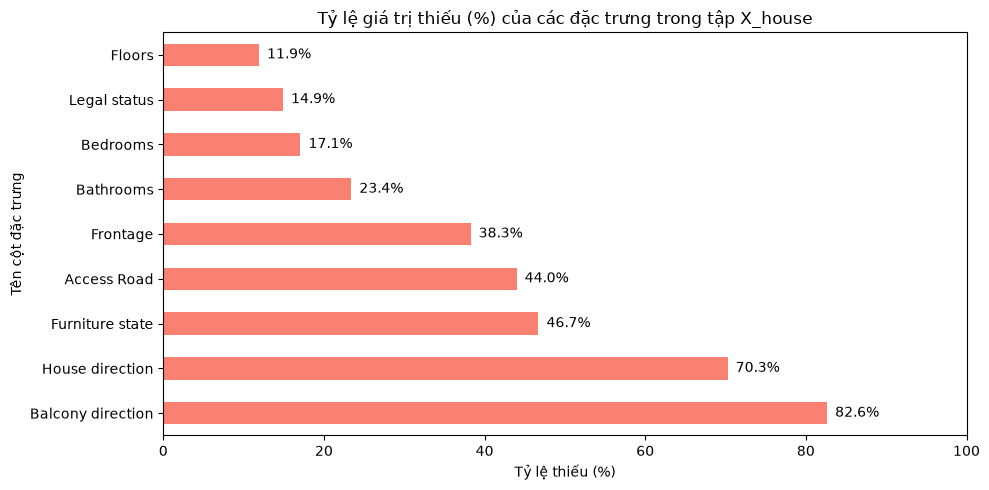

In [3]:
X_house = df_housing.drop(columns=['Price'])
y_house = df_housing['Price']

print(f"Kích thước ma trận đặc trưng X: {X_house.shape}")
print(f"Kích thước véc-tơ mục tiêu y: {y_house.shape}")

# Biểu đồ trực quan hóa tỷ lệ giá trị thiếu (Missing Values) trong tập đặc trưng X_house
plt.figure(figsize=(10, 5))
missing_percentage = (X_house.isnull().sum() / len(X_house)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_percentage.plot(kind='barh', color='salmon')
plt.title('Tỷ lệ giá trị thiếu (%) của các đặc trưng trong tập X_house')
plt.xlabel('Tỷ lệ thiếu (%)')
plt.ylabel('Tên cột đặc trưng')
plt.xlim(0, 100)

for index, value in enumerate(missing_percentage):
    plt.text(value + 1, index, f"{value:.1f}%", va='center')

plt.tight_layout()
plt.show()

## Phần V: Phân tích Khám phá Dữ liệu (EDA)
Phân phối giá nhà và mối tương quan giữa diện tích và giá.

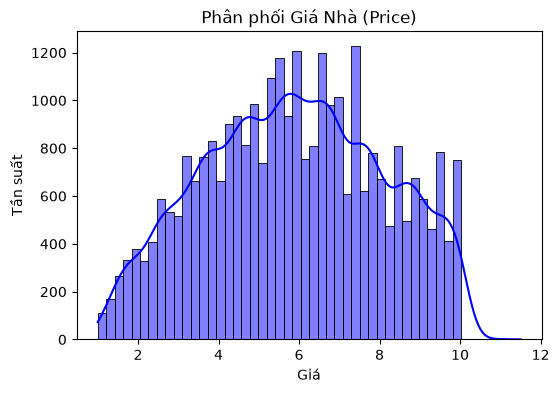

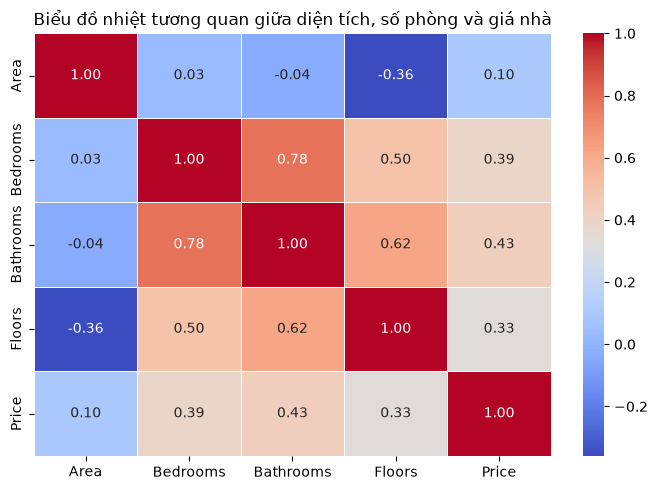

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df_housing['Price'], kde=True, color='blue')
plt.title('Phân phối Giá Nhà (Price)')
plt.xlabel('Giá')
plt.ylabel('Tần suất')
plt.show()

# Quan sát: Phân phối giá nhà lệch phải rõ rệt.
# Diễn giải: Đa số nhà có mức giá phổ thông, một số ít có giá trị rất cao (outliers).
# Ý nghĩa học máy: Các mô hình tuyến tính có thể bị ảnh hưởng bởi giá trị lớn, cần chuẩn hóa hoặc đánh giá dựa trên MAE/RMSE.

# Tính toán ma trận tương quan (Correlation Matrix) giữa các biến số quan trọng
selected_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Price']
corr_matrix = df_housing[selected_features].corr()

# Vẽ biểu đồ nhiệt (Heatmap) thể hiện mối quan hệ tương quan
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Biểu đồ nhiệt tương quan giữa diện tích, số phòng và giá nhà')
plt.tight_layout()
plt.show()


## Phần VI: Phân chia Dữ liệu
Phân chia theo tỷ lệ 80% huấn luyện, 20% kiểm tra.

In [5]:
from sklearn.model_selection import train_test_split

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)
print("Tập huấn luyện:", X_train_h.shape)
print("Tập kiểm tra:", X_test_h.shape)


Tập huấn luyện: (24183, 11)
Tập kiểm tra: (6046, 11)


## Phần VII & VIII: Phát triển và Đánh giá 5 Mô hình Hồi quy
So sánh: Linear Regression, Ridge, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

num_cols_h = X_house.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_h = X_house.select_dtypes(include=['object', 'str']).columns.tolist()

# Tạo pipeline xử lý cho cột số (Điền giá trị thiếu bằng median, sau đó chuẩn hóa)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Tạo pipeline xử lý cho cột phân loại (Điền giá trị thiếu bằng chuỗi phổ biến, sau đó OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_h = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols_h),
    ('cat', categorical_transformer, cat_cols_h)
])

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=50),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

reg_results = []
trained_reg_pipelines = {}

for name, reg in reg_models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_h),
        ('regressor', reg)
    ])
    pipeline.fit(X_train_h, y_train_h)
    y_pred = pipeline.predict(X_test_h)
    
    mae = mean_absolute_error(y_test_h, y_pred)
    mse = mean_squared_error(y_test_h, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_h, y_pred)
    
    reg_results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
    trained_reg_pipelines[name] = pipeline

df_reg_res = pd.DataFrame(reg_results)
display(df_reg_res)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1.266833,3.518447,1.875752,0.278402
1,Ridge Regression,1.268067,2.769414,1.664156,0.432022
2,Decision Tree,1.557006,4.597075,2.144079,0.057187
3,Random Forest,1.313590,3.001658,1.732529,0.384391
4,Gradient Boosting,1.476284,3.331037,1.825113,0.316838


## Phần IX: So sánh Mô hình & Biện minh lựa chọn
Lựa chọn Random Forest Regressor hoặc Gradient Boosting dựa trên chỉ số $R^2$.

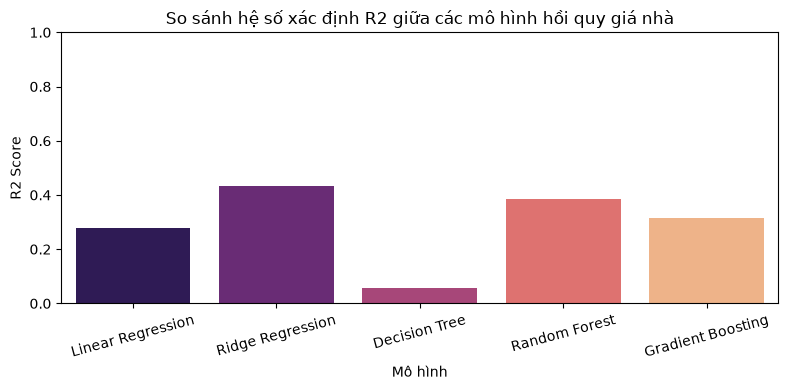

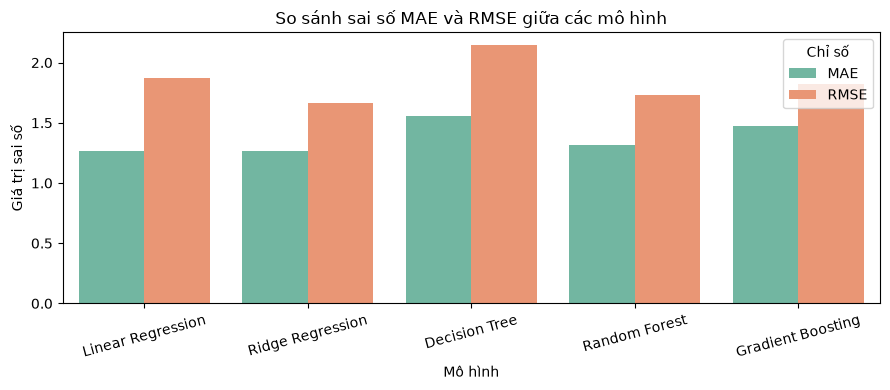

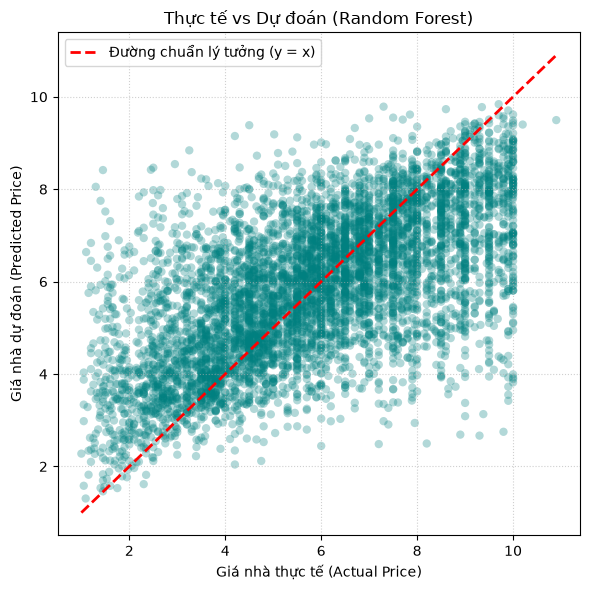

In [9]:
# 1. Biểu đồ so sánh hệ số xác định R2
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='R2', hue='Model', data=df_reg_res, palette='magma', legend=False)
plt.title('So sánh hệ số xác định R2 giữa các mô hình hồi quy giá nhà')
plt.ylim(0, 1.0)
plt.ylabel('R2 Score')
plt.xlabel('Mô hình')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2. Biểu đồ so sánh các sai số (MAE, RMSE)
df_error_melted = df_reg_res.melt(id_vars='Model', value_vars=['MAE', 'RMSE'], var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 4))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_error_melted, palette='Set2')
plt.title('So sánh sai số MAE và RMSE giữa các mô hình')
plt.xlabel('Mô hình')
plt.ylabel('Giá trị sai số')
plt.legend(title='Chỉ số')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 3. Biểu đồ Scatter Plot so sánh Giá trị Thực tế vs Dự đoán của mô hình tốt nhất (Random Forest)
best_model_name = "Random Forest"
best_pipeline = trained_reg_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test_h)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_h, y_pred_best, alpha=0.3, color='teal', edgecolors='none')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2, label='Đường chuẩn lý tưởng (y = x)')
plt.title(f'Thực tế vs Dự đoán ({best_model_name})')
plt.xlabel('Giá nhà thực tế (Actual Price)')
plt.ylabel('Giá nhà dự đoán (Predicted Price)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Phần X: Lưu trữ Mô hình (Persistence)
Lưu pipeline hồi quy tốt nhất.

In [8]:
import joblib

best_reg_pipeline = trained_reg_pipelines["Random Forest"]
joblib.dump(best_reg_pipeline, "housing_model_pipeline.joblib")
print("Đã lưu pipeline mô hình giá nhà thành công vào 'housing_model_pipeline.joblib'")


Đã lưu pipeline mô hình giá nhà thành công vào 'housing_model_pipeline.joblib'
